<a href="https://colab.research.google.com/github/peakodev/data_science/blob/main/home_07/HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 7

## Utils from Leonid

In [38]:
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def invert_dictionary(dictionary):
    return {v: k for k, v in dictionary.items()}

def surprise_train_set_to_df(train_set, col_user="uid", col_item="iid", col_rating="rating"):
    df = pd.DataFrame(train_set.all_ratings(), columns=[col_user, col_item, col_rating])
    map_user = train_set._inner2raw_id_users if train_set._inner2raw_id_users is not None else invert_dictionary(train_set._raw2inner_id_users)
    map_item = train_set._inner2raw_id_items if train_set._inner2raw_id_items is not None else invert_dictionary(train_set._raw2inner_id_items)
    df[col_user] = df[col_user].map(map_user)
    df[col_item] = df[col_item].map(map_item)
    return df

# Функція для виведення топ-N рекомендацій
def get_top_n(predictions, n=10):
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]
    return top_n

## Load movielens 100k

In [39]:
# Налаштування середовища
!pip install scikit-surprise

In [40]:
import pandas as pd
from surprise import Dataset, Reader, SVD, NMF, SVDpp, BaselineOnly, KNNWithMeans, KNNBaseline
from surprise.model_selection import train_test_split, cross_validate
from surprise import accuracy
from surprise.accuracy import rmse

In [41]:
# Завантаження датасету ml-1m
data = Dataset.load_builtin("ml-100k")

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k


In [42]:
train_set, test_set = train_test_split(data, test_size=0.25, random_state=42)

## EDA

In [43]:
train_set_df = surprise_train_set_to_df(train_set)

In [44]:
train_set_df.head()

,uid,iid,rating
0,877,381,4.0
1,877,451,4.0
2,877,557,4.0
3,877,692,4.0
4,877,56,5.0


In [45]:
len(train_set_df)

75000

In [46]:
train_set_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   uid     75000 non-null  object 
 1   iid     75000 non-null  object 
 2   rating  75000 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.7+ MB


In [47]:
train_set_df.describe()

,rating
count,75000.00000
mean,3.53064
std,1.12433
min,1.00000
25%,3.00000
50%,4.00000
75%,4.00000
max,5.00000


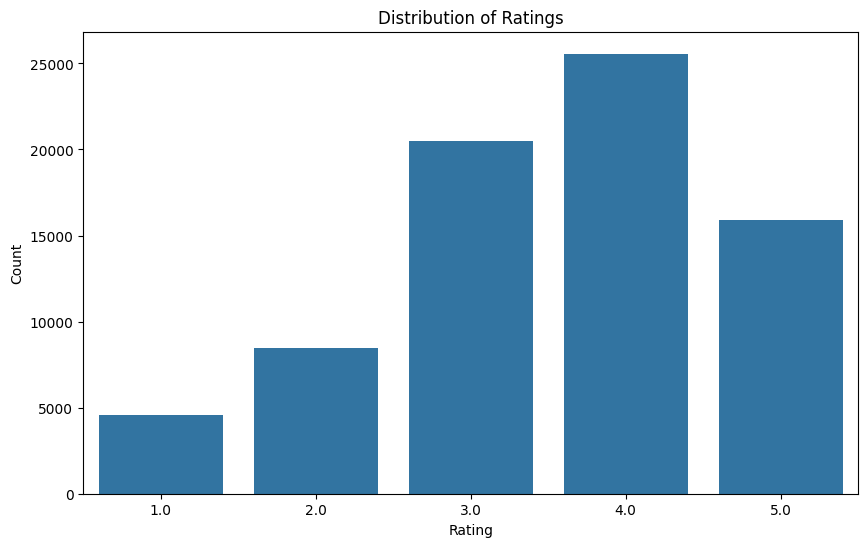

In [48]:
plt.figure(figsize=(10,6))
sns.countplot(x='rating', data=train_set_df)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Ratings')
plt.show()

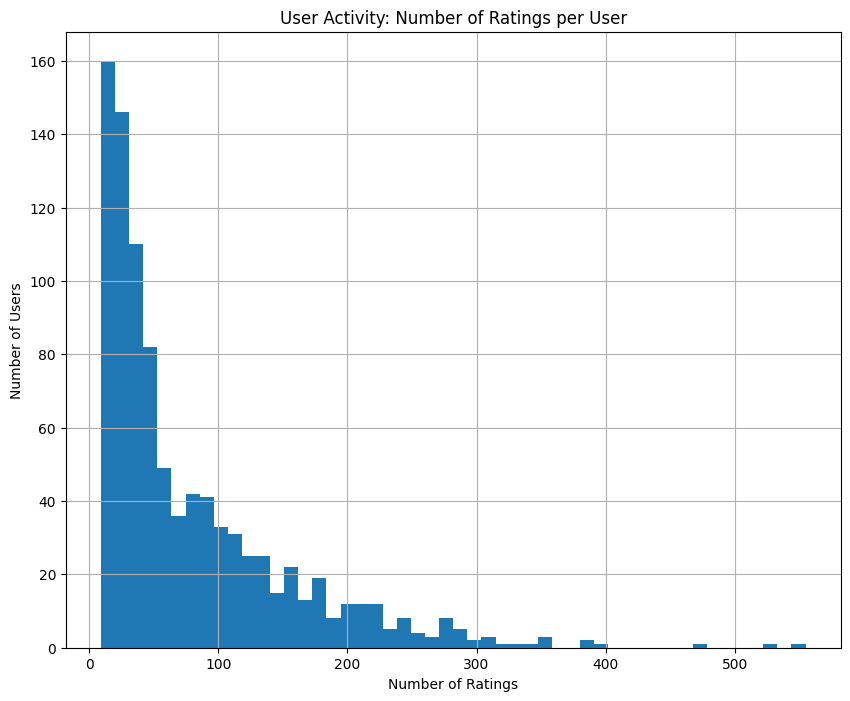

In [49]:
user_ratings_count = train_set_df.groupby('uid')['rating'].count().sort_values(ascending=False)
plt.figure(figsize=(10,8))
user_ratings_count.hist(bins=50)
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.title('User Activity: Number of Ratings per User')
plt.show()

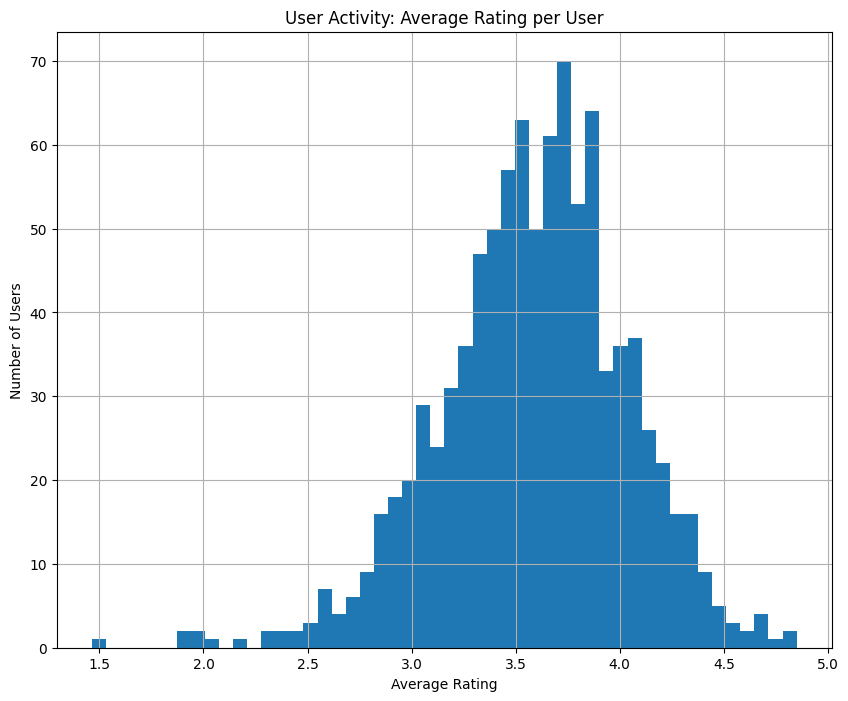

In [50]:
# average rating per user
avg_rating_per_user = train_set_df.groupby('uid')['rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,8))
avg_rating_per_user.hist(bins=50)
plt.xlabel('Average Rating')
plt.ylabel('Number of Users')
plt.title('User Activity: Average Rating per User')
plt.show()

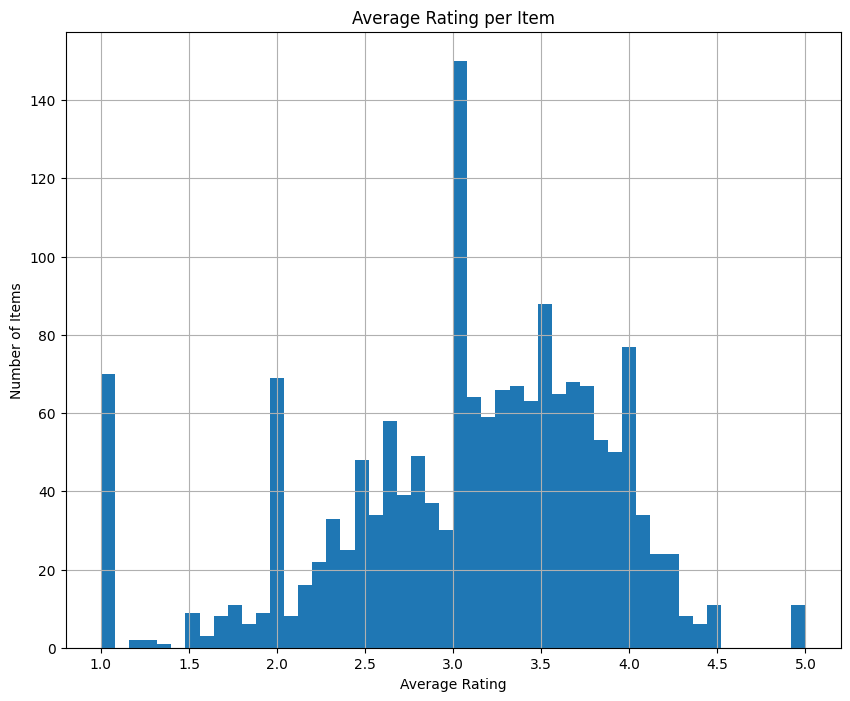

In [51]:
# average rating per item
avg_rating_per_item = train_set_df.groupby('iid')['rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,8))
avg_rating_per_item.hist(bins=50)
plt.xlabel('Average Rating')
plt.ylabel('Number of Items')
plt.title("Average Rating per Item")
plt.show()

In [52]:
# Sparsity of the Rating Matrix (important for collaborative filtering)
num_users = train_set_df["uid"].nunique()
num_items = train_set_df["iid"].nunique()
num_ratings = len(train_set_df)

In [53]:
sparsity = 1 - (num_ratings / (num_users * num_items))
print(f"Sparsity of the rating matrix: {sparsity:.4f}")

Sparsity of the rating matrix: 0.9516


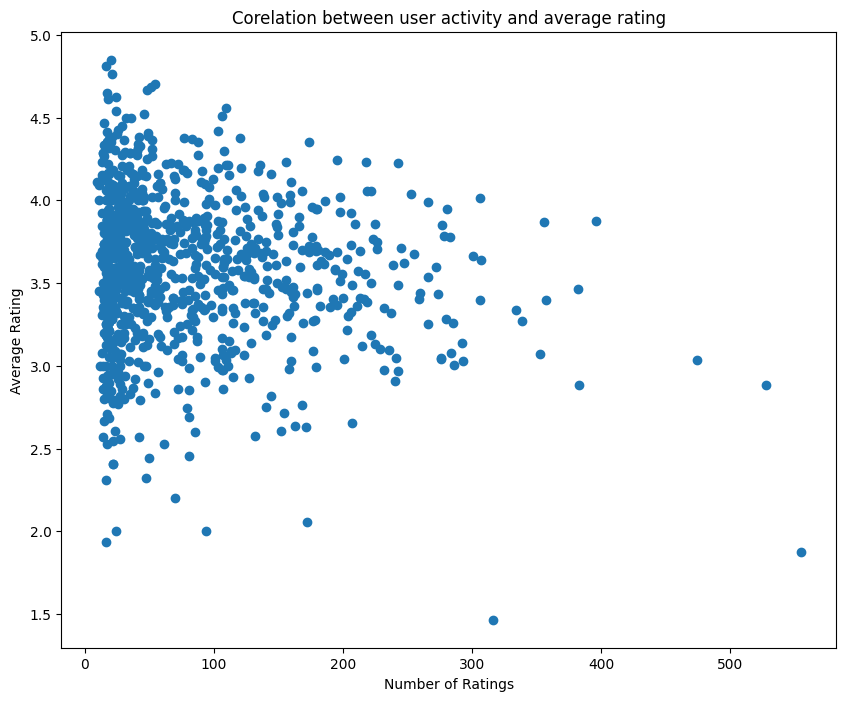

In [54]:
# corelation between user activity and average rating
user_stats = train_set_df.groupby('uid').agg({'rating': ['count', 'mean']})
plt.figure(figsize=(10,8))
plt.scatter(user_stats['rating']['count'], user_stats['rating']['mean'])
plt.xlabel('Number of Ratings')
plt.ylabel('Average Rating')
plt.title('Corelation between user activity and average rating')
plt.show()

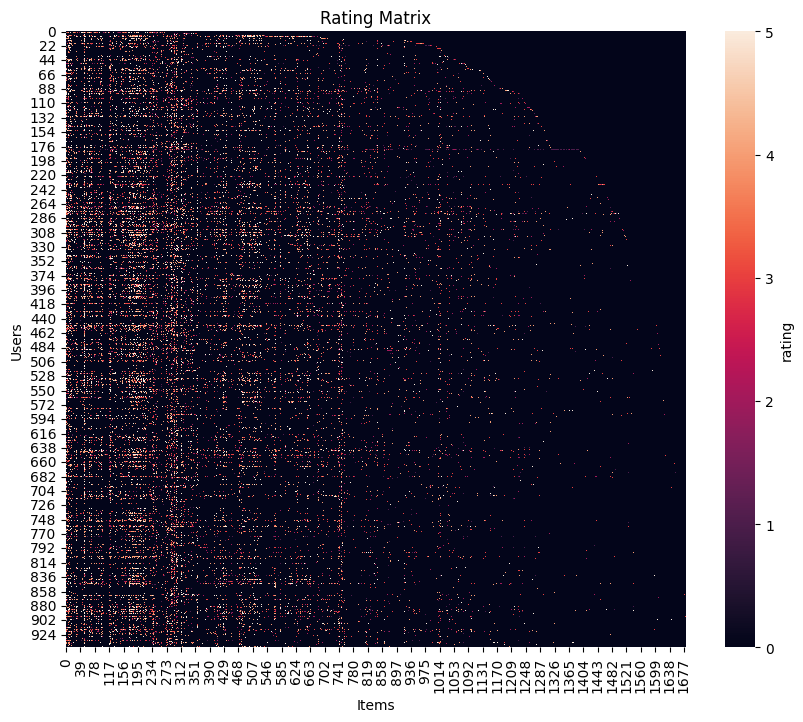

In [55]:
from scipy.sparse import csr_matrix

# visualization of matrix rating
rating_matrix = csr_matrix((train_set_df['rating'], (train_set_df['uid'].to_numpy(dtype=int), train_set_df['iid'].to_numpy(dtype=int))))
plt.figure(figsize=(10,8))
sns.heatmap(rating_matrix.todense(), cbar_kws={'label': 'rating'})
plt.xlabel('Items')
plt.ylabel('Users')
plt.title('Rating Matrix')
plt.show()

## SVD

In [61]:
from surprise.model_selection import GridSearchCV

# Define the parameter grid for SVD
param_grid = {
    "n_factors": [9, 10, 12],
    "n_epochs": [22, 24, 26],
    "lr_all": [0.005, 0.007, 0.009],
    "reg_all": [0.01, 0.02, 0.04]
}

gs = GridSearchCV(SVD, param_grid, measures=["rmse", "mae"], cv=3)
gs.fit(data)

gs.best_score, gs.best_params

({'rmse': 0.9319460673818082, 'mae': 0.7335528245413642},
 {'rmse': {'n_factors': 9, 'n_epochs': 24, 'lr_all': 0.009, 'reg_all': 0.04},
  'mae': {'n_factors': 9, 'n_epochs': 24, 'lr_all': 0.009, 'reg_all': 0.04}})

In [62]:
svd = SVD(n_factors=9, n_epochs=24, lr_all=0.009, reg_all=0.04)
svd.fit(train_set)
predictions = svd.test(test_set)
accuracy.rmse(predictions)

RMSE: 0.9347


0.9347480025461083

## SVD++

In [65]:
from surprise.model_selection import GridSearchCV

# Define the parameter grid for SVDpp
param_grid = {
    "n_factors": [10, 12],
    "n_epochs": [24, 26]
}

gs = GridSearchCV(SVDpp, param_grid, measures=["rmse", "mae"], cv=3)
gs.fit(data)

gs.best_score, gs.best_params

({'rmse': 0.92763370016777, 'mae': 0.7272137647998819},
 {'rmse': {'n_factors': 10, 'n_epochs': 24},
  'mae': {'n_factors': 10, 'n_epochs': 24}})

In [66]:
svdpp = SVDpp(n_factors=9, n_epochs=24, lr_all=0.009, reg_all=0.04)
svdpp.fit(train_set)
predictions = svdpp.test(test_set)
accuracy.rmse(predictions)

RMSE: 0.9224


0.9224485149084296

## NNF

In [68]:
from surprise.model_selection import GridSearchCV

# Define the parameter grid for NMF
param_grid = {
    "n_factors": [10, 12, 20],
    "n_epochs": [24, 26, 30]
}

gs = GridSearchCV(NMF, param_grid, measures=["rmse", "mae"], cv=3)
gs.fit(data)

gs.best_score, gs.best_params

({'rmse': 0.9849778594705468, 'mae': 0.784958337126958},
 {'rmse': {'n_factors': 12, 'n_epochs': 30},
  'mae': {'n_factors': 20, 'n_epochs': 30}})

In [69]:
nmf = NMF(n_factors=12, n_epochs=30)
nmf.fit(train_set)
predictions = nmf.test(test_set)
accuracy.rmse(predictions)

RMSE: 0.9841


0.9841327426424794